# XGBoost Classifier - PS-S06E10: Predicting Airline Satisfaction

This notebook trains an **XGBoost Classifier** using GPU acceleration (`device="cuda"`, `tree_method="hist"`).
It implements `FeatureFactory` feature engineering, Optuna hyperparameter optimization with fold caching, and multi-seed Stratified K-Fold CV evaluated on **ROC AUC**.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e10_experiment_setup import ExperimentSetup
from ps_s06e10_feature_engineering import FeatureFactory
from ps_s06e10_model_visualizer import ModelVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='XGBoost',
    use_gpu=True,
    perform_optuna_tuning=True
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'satisfaction'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id  Age  Flight Distance  Inflight wifi service  \
0   0   36              694                      4   
1   1   56              651                      5   
2   2   31             1371                      3   
3   3   10             1616                      3   
4   4   23              481                      3   

   Departure/Arrival time convenient  Ease of Online booking  Gate location  \
0                                  4                       4              3   
1                                  5                       5              5   
2                                  4                       2              5   
3                                  5                       3              3   
4                                  4                       3              4   

   Food and drink  Online boarding  Seat comfort  Inflight entertainment  \
0               1                4             1                       1   
1               5             

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'service_aggregations',
    'delay_features',
    'satisfaction_scores',
    'flight_ratios',
    'group_aggregations',
    'missing_flags',
    'rating_zero_flags',
    'target_mapped_ratings'
]

ff = FeatureFactory(strategies=fe_strategies, verbose=True)
X = ff.fit_transform(training_df)
y = training_df[TARGET].astype(int)

X_test = ff.transform(test_df)

print(f'Engineered Train shape: {X.shape}')
print(f'Engineered Test shape:  {X_test.shape}')

  -> Fitting FeatureFactory...
Applying FeatureFactory with strategies: encoding, service_aggregations, delay_features, satisfaction_scores, flight_ratios, group_aggregations, missing_flags, rating_zero_flags, target_mapped_ratings
Applying FeatureFactory with strategies: encoding, service_aggregations, delay_features, satisfaction_scores, flight_ratios, group_aggregations, missing_flags, rating_zero_flags, target_mapped_ratings
Engineered Train shape: (699635, 129)
Engineered Test shape:  (299844, 129)


## 4. Hyperparameter Tuning (Optuna + SQLite Storage)

In [5]:
optuna_filename = 'optuna_params_xgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print('Starting Optuna hyperparameter optimization...')

    # Fold Cache Pattern
    skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_cache = []
    for tr_idx, val_idx in skf_cv.split(X, y):
        fold_cache.append((
            X.iloc[tr_idx].copy(),
            X.iloc[val_idx].copy(),
            y.iloc[tr_idx].copy(),
            y.iloc[val_idx].copy()
        ))

    def objective(trial):
        params = {
            'device': 'cuda' if setup.use_gpu() else 'cpu',
            'tree_method': 'hist',
            'eval_metric': 'auc',
            'objective': 'binary:logistic',
            'enable_categorical': True,
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_int('min_child_weight', 3, 150),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.95),
            'gamma': trial.suggest_float('gamma', 1e-8, 10.0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 30.0, log=True),
            'n_estimators': 1500,
            'random_state': seed,
        }

        scores = []
        for fold_idx, (X_tr, X_val, y_tr, y_val) in enumerate(fold_cache):
            model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
            val_preds = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, val_preds)
            scores.append(score)

            trial.report(score, step=fold_idx)
            if trial.should_prune():
                raise optuna.TrialPruned()

        return np.mean(scores)

    study = optuna.create_study(
        study_name='xgb_tuning_s06e10_v1',
        storage='sqlite:///xgb_study.db',
        load_if_exists=True,
        direction='maximize',
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True
        )
    )

    if best_params is None or len(best_params) == 0:
        best_params = {
            'learning_rate': 0.05,
            'max_depth': 6,
            'min_child_weight': 10,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'gamma': 1e-4,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0
        }

    study.enqueue_trial(best_params)

    study.optimize(
        objective,
        n_trials=50,
        timeout=10800,
        show_progress_bar=True
    )

    print(f'Best Trial ROC AUC: {study.best_value:.6f}')
    best_params = study.best_params
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    print('Using default or cached XGBoost parameters:', best_params)

Loaded 8 parameters from optuna_params_xgb.json
Starting Optuna hyperparameter optimization...


[I 2026-10-05 13:34:57,962] A new study created in RDB with name: xgb_tuning_s06e10_v1


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-10-05 13:36:18,587] Trial 0 finished with value: 0.9591439325691817 and parameters: {'learning_rate': 0.026593280866719603, 'max_depth': 7, 'min_child_weight': 40, 'subsample': 0.9238488647158803, 'colsample_bytree': 0.43021166052521614, 'gamma': 2.3049022857581867e-06, 'reg_alpha': 1.7029774120639148e-06, 'reg_lambda': 0.034926269577534134}. Best is trial 0 with value: 0.9591439325691817.
[I 2026-10-05 13:37:25,709] Trial 1 finished with value: 0.9587691500183132 and parameters: {'learning_rate': 0.09232905818945426, 'max_depth': 4, 'min_child_weight': 138, 'subsample': 0.9009450147359245, 'colsample_bytree': 0.5698144562206617, 'gamma': 0.07624411838104503, 'reg_alpha': 9.438506245769279, 'reg_lambda': 0.9470760925203034}. Best is trial 0 with value: 0.9591439325691817.
[I 2026-10-05 13:38:23,731] Trial 2 finished with value: 0.9589101509885853 and parameters: {'learning_rate': 0.04648167012029156, 'max_depth': 6, 'min_child_weight': 91, 'subsample': 0.8069210090151978, 'cols

100%|██████████| 1.00k/1.00k [00:00<00:00, 1.51MB/s]


...

Upload successful: optuna_params_lgb.json (257B)
Starting upload for file optuna_params_catboost.json


100%|██████████| 202/202 [00:00<00:00, 384B/s]


Upload successful: optuna_params_catboost.json (202B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 269/269 [00:00<00:00, 520B/s]


Upload successful: optuna_params_xgb.json (269B)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e10-artifacts
Kaggle artifacts dataset upload completed successfully!


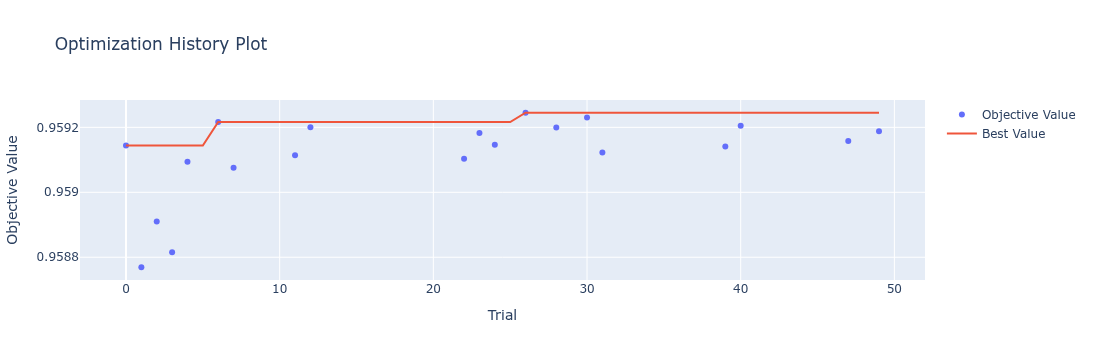

In [6]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except Exception as e:
    print(f"Plot optimization history skipped: {e}")

## 5. Model Training & Multi-Seed Blending

In [7]:
seeds = setup.seed()
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.ones(len(X), dtype=bool)

models = []
eval_results = []
seed_scores = {}

base_params = {
    'device': 'cuda' if setup.use_gpu() else 'cpu',
    'tree_method': 'hist',
    'eval_metric': 'auc',
    'objective': 'binary:logistic',
    'enable_categorical': True,
    'n_estimators': 2000,
    **best_params
}

for current_seed in seeds:
    print(f'\n--- Training XGBoost across 5 Folds with Seed {current_seed} ---')
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    seed_oof = np.zeros(len(X))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = xgb.XGBClassifier(**base_params, random_state=current_seed, early_stopping_rounds=100)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        val_pred_prob = model.predict_proba(X_val)
        seed_oof[val_idx] = val_pred_prob[:, 1]

        oof_probs[val_idx, 0] += val_pred_prob[:, 0] / len(seeds)
        oof_probs[val_idx, 1] += val_pred_prob[:, 1] / len(seeds)

        test_pred_prob = model.predict_proba(X_test)
        test_probs[:, 0] += test_pred_prob[:, 0] / (len(seeds) * 5)
        test_probs[:, 1] += test_pred_prob[:, 1] / (len(seeds) * 5)

        models.append(model)
        eval_results.append(model.evals_result())

        fold_auc = roc_auc_score(y_val, val_pred_prob[:, 1])
        print(f'Seed {current_seed} | Fold {fold+1} ROC AUC: {fold_auc:.6f}')

    seed_auc = roc_auc_score(y, seed_oof)
    seed_scores[current_seed] = seed_auc
    print(f'>>> Seed {current_seed} OOF ROC AUC: {seed_auc:.6f}')

print('\n==========================================')
for s, score in seed_scores.items():
    print(f'Seed {s:<5} OOF ROC AUC: {score:.6f}')
overall_auc = roc_auc_score(y, oof_probs[:, 1])
print('------------------------------------------')
print(f'Overall Multi-Seed OOF ROC AUC: {overall_auc:.6f}')
print('==========================================')


--- Training XGBoost across 5 Folds with Seed 10301 ---
Seed 10301 | Fold 1 ROC AUC: 0.961225
Seed 10301 | Fold 2 ROC AUC: 0.959381
Seed 10301 | Fold 3 ROC AUC: 0.958684
Seed 10301 | Fold 4 ROC AUC: 0.958844
Seed 10301 | Fold 5 ROC AUC: 0.958203
>>> Seed 10301 OOF ROC AUC: 0.959247

--- Training XGBoost across 5 Folds with Seed 42 ---
Seed 42 | Fold 1 ROC AUC: 0.959181
Seed 42 | Fold 2 ROC AUC: 0.958057
Seed 42 | Fold 3 ROC AUC: 0.959967
Seed 42 | Fold 4 ROC AUC: 0.959206
Seed 42 | Fold 5 ROC AUC: 0.959352
>>> Seed 42 OOF ROC AUC: 0.959149

--- Training XGBoost across 5 Folds with Seed 2026 ---
Seed 2026 | Fold 1 ROC AUC: 0.959644
Seed 2026 | Fold 2 ROC AUC: 0.959092
Seed 2026 | Fold 3 ROC AUC: 0.959425
Seed 2026 | Fold 4 ROC AUC: 0.958847
Seed 2026 | Fold 5 ROC AUC: 0.959281
>>> Seed 2026 OOF ROC AUC: 0.959251

--- Training XGBoost across 5 Folds with Seed 777 ---
Seed 777 | Fold 1 ROC AUC: 0.960383
Seed 777 | Fold 2 ROC AUC: 0.959072
Seed 777 | Fold 3 ROC AUC: 0.959338
Seed 777 | Fo

## 6. Performance Visualization

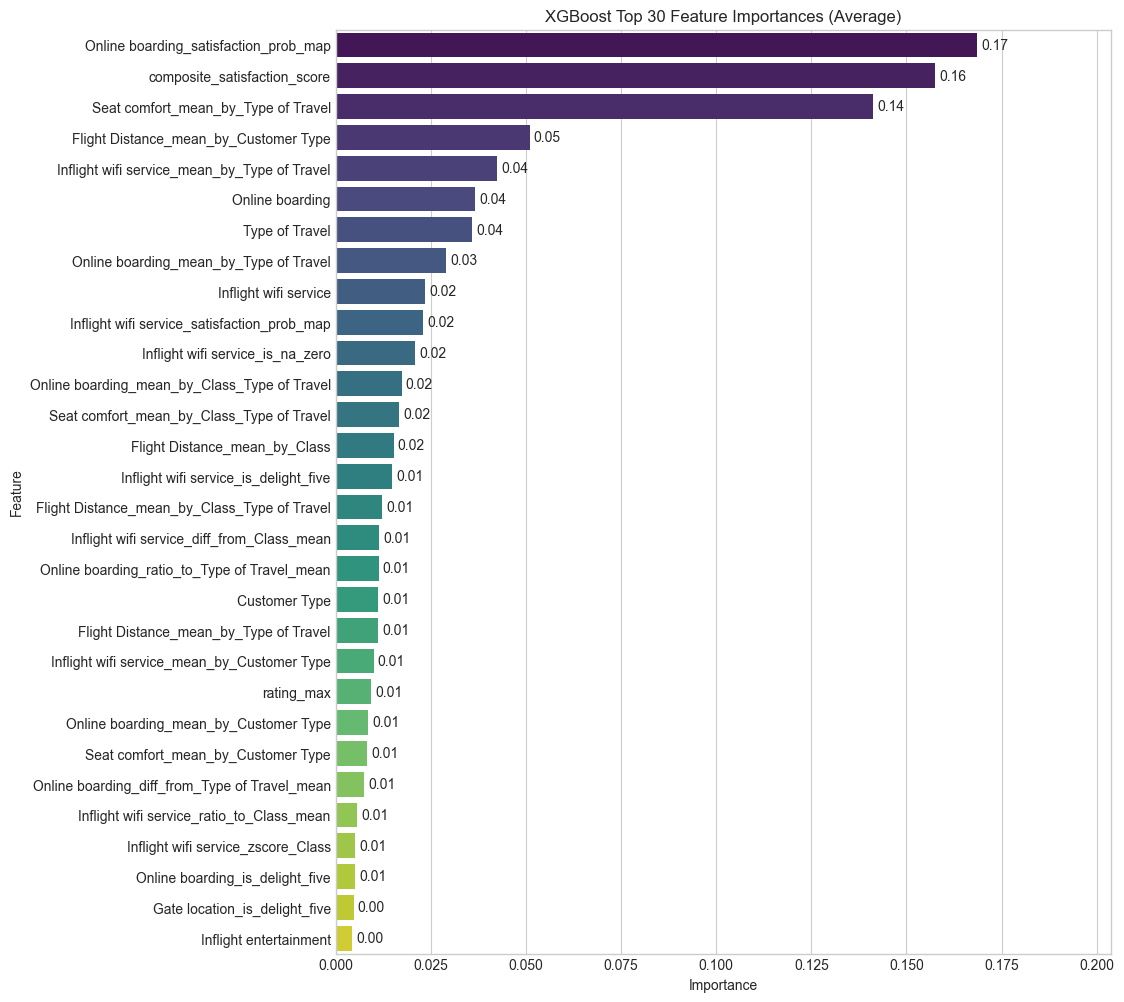

In [8]:
mviz = ModelVisualizer(model_name='XGBoost')
mviz.plot_feature_importance(models[:5], show_values=True)

<Figure size 800x600 with 0 Axes>

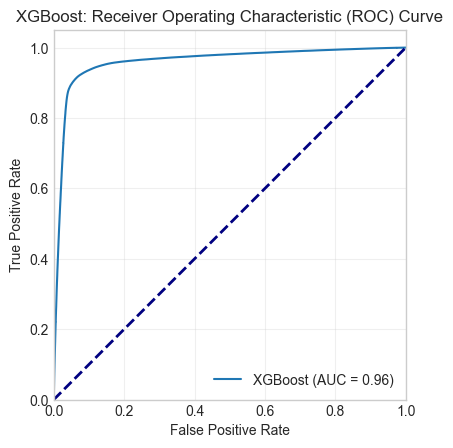

In [9]:
mviz.plot_roc_curve(y_true=y, y_score=oof_probs[:, 1])

Confusion matrix, without normalization


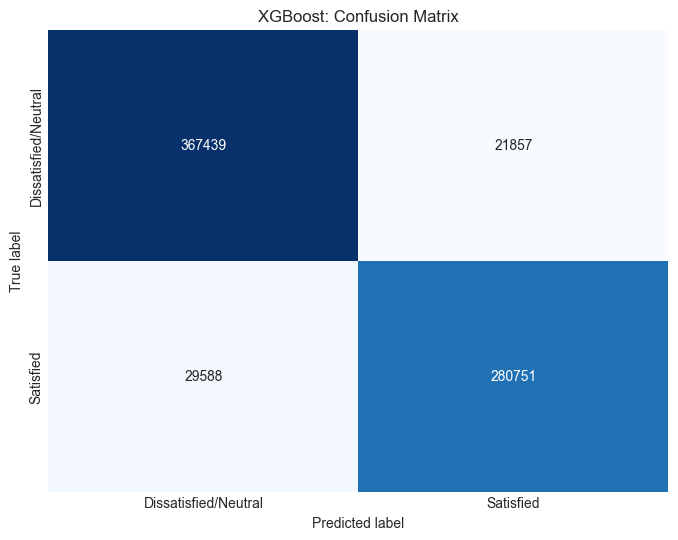

In [10]:
y_pred_class = (oof_probs[:, 1] >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y, y_pred=y_pred_class, classes=['Dissatisfied/Neutral', 'Satisfied'])

## 7. Export Submission & Predictions

In [11]:
submission_df = setup.read_dataset('submission')
submission_df[TARGET] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print('Saved submission.csv successfully!')

setup.save_probabilities('xgb', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved submission.csv successfully!
Saved for ensembling:
 - predictions/xgb_oof_probs.csv
 - predictions/xgb_test_probs.csv
